# Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch1 2026-2027 — Major Project**

**Student:** Deepika Singh (Deepu) | B.Tech CSE, Jaypee University of Information Technology (JUIT), Solan | Enrollment No. 241030016

This notebook analyzes seasonal agricultural performance across Kharif, Rabi and Zaid seasons using a multi-state farm-level dataset, to identify patterns, trends, relationships and differences in yield, economics, resource usage and risk.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
df.shape

(4000, 28)

In [2]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


## 2. Data Cleaning & Preparation

- Missing rainfall and soil-moisture values are filled with the season-wise median.
- Missing yield values are filled with the median for the same crop-season combination.
- Extreme yield outliers are capped (IQR method, per season) into a `Yield_clean` column so seasonal averages aren't skewed by a few extreme records.
- A `Profit_margin_pct` column is derived as `Profit / Revenue * 100`.

In [5]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [6]:
df['Rainfall_mm'] = df.groupby('Season')['Rainfall_mm'].transform(lambda x: x.fillna(x.median()))
df['Soil_Moisture_pct'] = df.groupby('Season')['Soil_Moisture_pct'].transform(lambda x: x.fillna(x.median()))
df['Yield_Tonnes_Ha'] = df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha'].transform(lambda x: x.fillna(x.median()))

def cap_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return s.clip(lo, hi)

df['Yield_clean'] = df.groupby('Season')['Yield_Tonnes_Ha'].transform(cap_outliers)
df['Profit_margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100

df.isnull().sum().sum()

np.int64(0)

In [7]:
season_order = ['Kharif', 'Rabi', 'Zaid']
df['Season'] = pd.Categorical(df['Season'], categories=season_order, ordered=True)
df.to_csv('cleaned_dataset.csv', index=False)

## 3. Question 1 — How does agricultural performance vary across seasons?

Comparing the number of records and average yield across the three seasons.

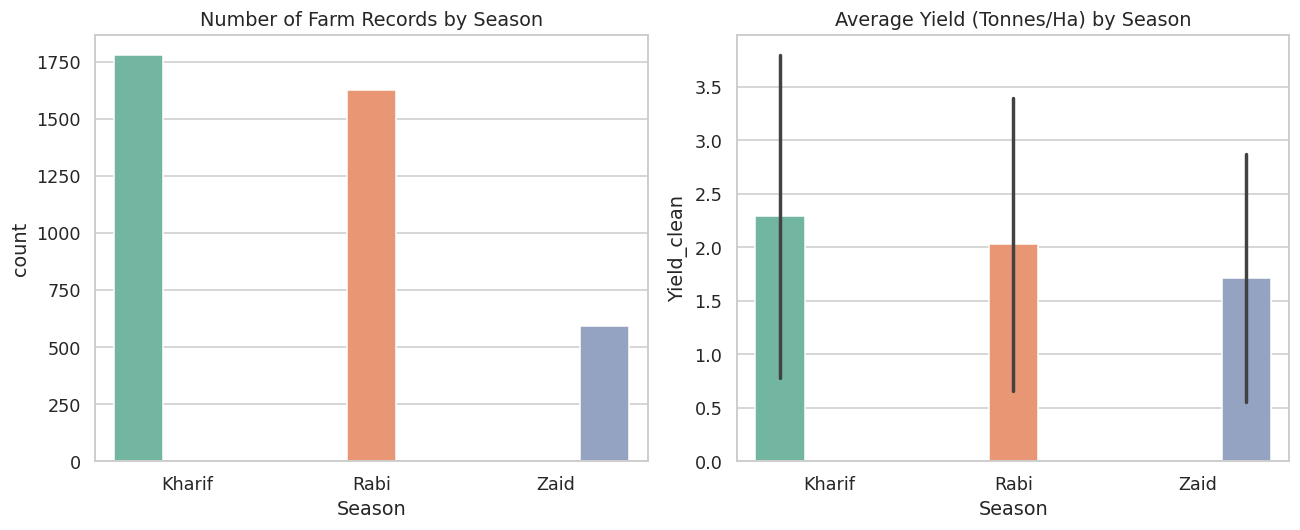

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x='Season', order=season_order, ax=axes[0], hue='Season', legend=False)
axes[0].set_title('Number of Farm Records by Season')
sns.barplot(data=df, x='Season', y='Yield_clean', order=season_order, ax=axes[1], hue='Season', legend=False, errorbar='sd')
axes[1].set_title('Average Yield (Tonnes/Ha) by Season')
plt.tight_layout()
plt.show()

**Observation:** Kharif has the most records (1,779) and the highest average yield (~2.29 t/ha), followed by Rabi (1,627 records, ~2.03 t/ha). Zaid has the fewest records (594) and the lowest average yield (~1.71 t/ha).

## 4. Question 2 — What major seasonal climate patterns can be observed?

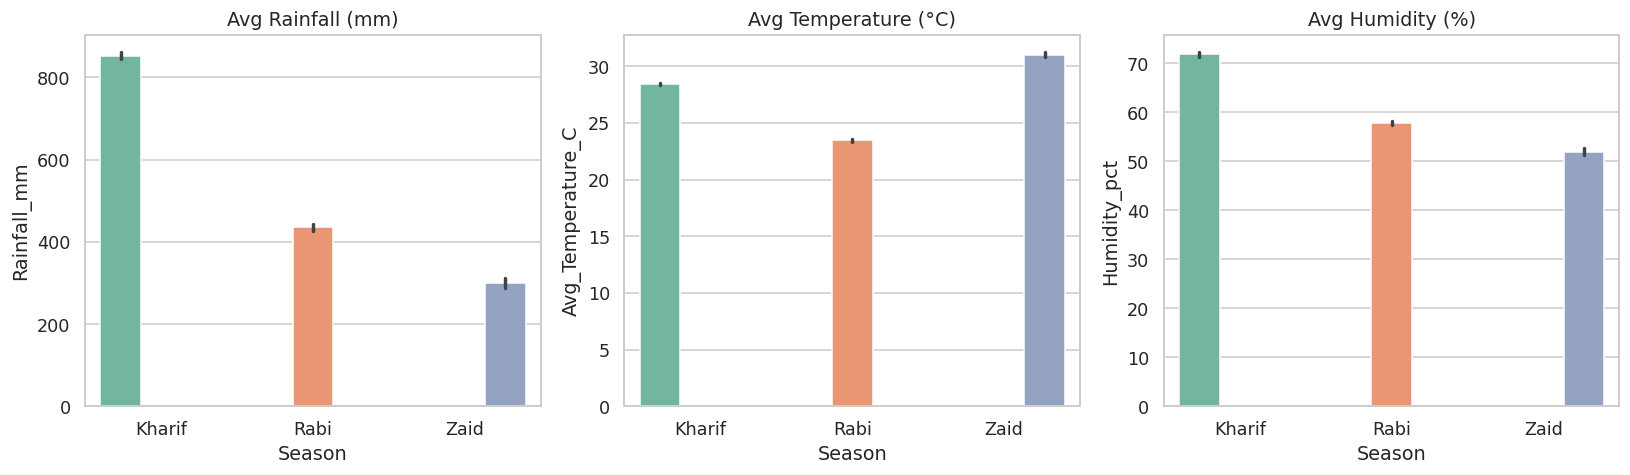

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, title in zip(axes, ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct'],
                           ['Avg Rainfall (mm)', 'Avg Temperature (°C)', 'Avg Humidity (%)']):
    sns.barplot(data=df, x='Season', y=col, order=season_order, ax=ax, hue='Season', legend=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

**Observation:** Kharif is the wettest season (~852 mm rainfall) while Zaid is hottest (~31°C) and driest (~299 mm, ~52% humidity). Rabi is the coolest season (~23.5°C), consistent with winter cropping.

## 5. Question 3 — How do economic outcomes vary across seasons?

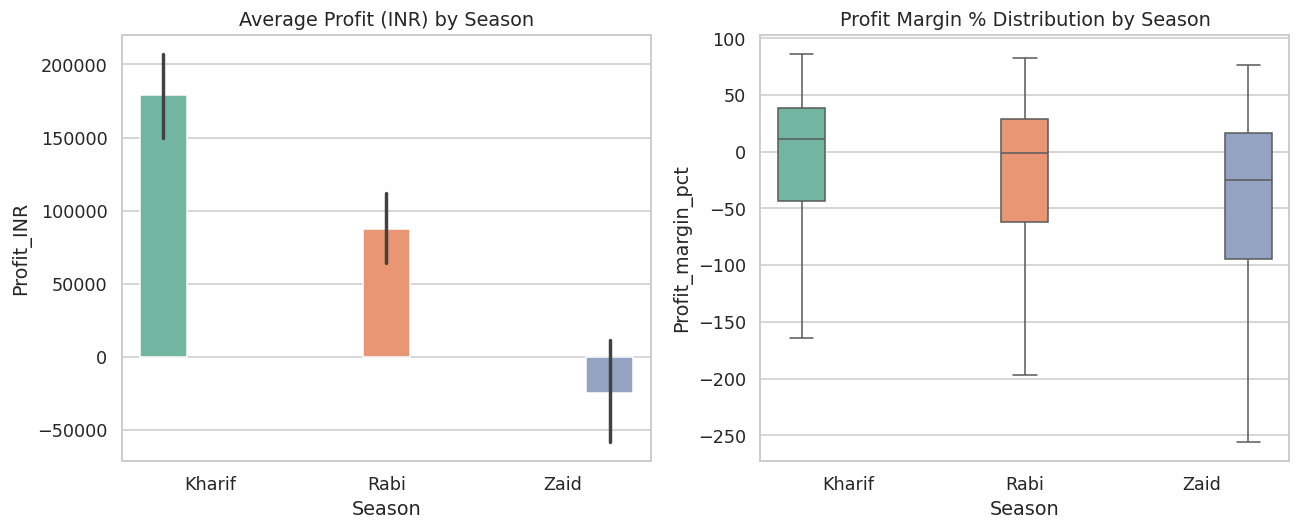

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=df, x='Season', y='Profit_INR', order=season_order, ax=axes[0], hue='Season', legend=False, estimator=np.mean)
axes[0].set_title('Average Profit (INR) by Season')
sns.boxplot(data=df, x='Season', y='Profit_margin_pct', order=season_order, ax=axes[1], hue='Season', legend=False, showfliers=False)
axes[1].set_title('Profit Margin % Distribution by Season')
plt.tight_layout()
plt.show()

**Observation:** Average profit is highest in Kharif (~₹1.79 lakh) and turns negative in Zaid (~₹−25K). Profit margins are negative on average in every season — production costs frequently exceed revenue — and Zaid shows the widest, most negative spread, making it the riskiest season economically.

## 6. Question 4 — Are there noticeable variations in resource usage across seasons?

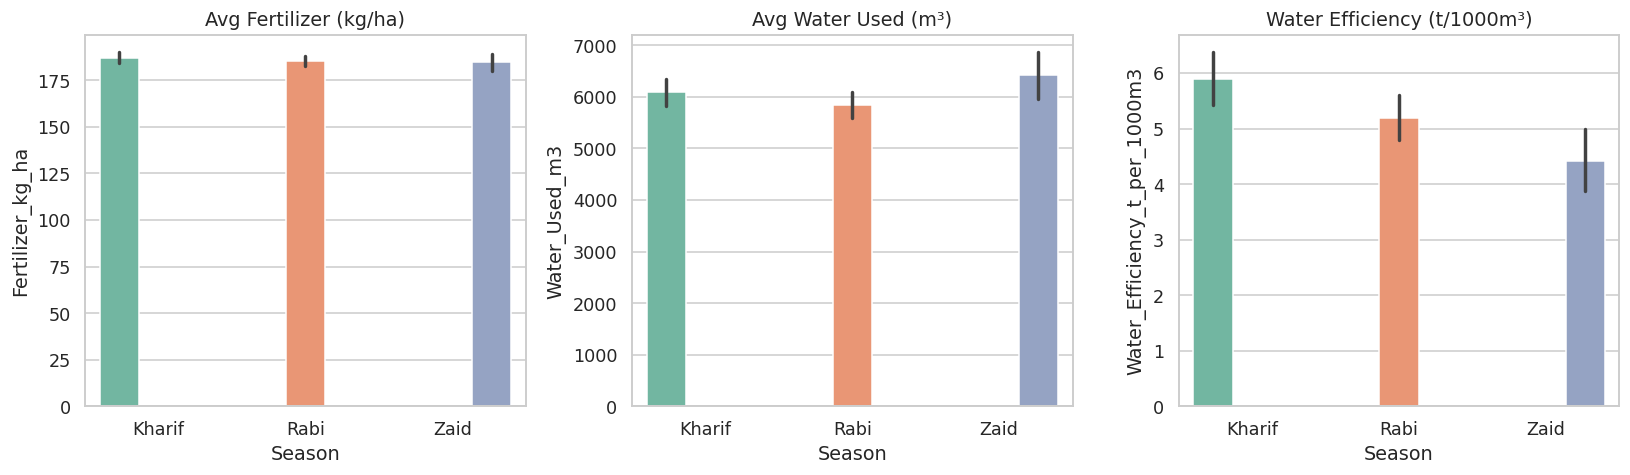

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, title in zip(axes, ['Fertilizer_kg_ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3'],
                           ['Avg Fertilizer (kg/ha)', 'Avg Water Used (m³)', 'Water Efficiency (t/1000m³)']):
    sns.barplot(data=df, x='Season', y=col, order=season_order, ax=ax, hue='Season', legend=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

**Observation:** Fertilizer use is nearly constant across seasons (~185–187 kg/ha), so it doesn't explain seasonal yield gaps. Water *volume* used is also similar across seasons, but water *efficiency* is markedly higher in Kharif (5.89 t/1000m³) than Zaid (4.41 t/1000m³) — efficiency, not volume, separates strong and weak seasons.

## 7. Question 5 — Are there relationships between seasonal environmental conditions and agricultural performance?

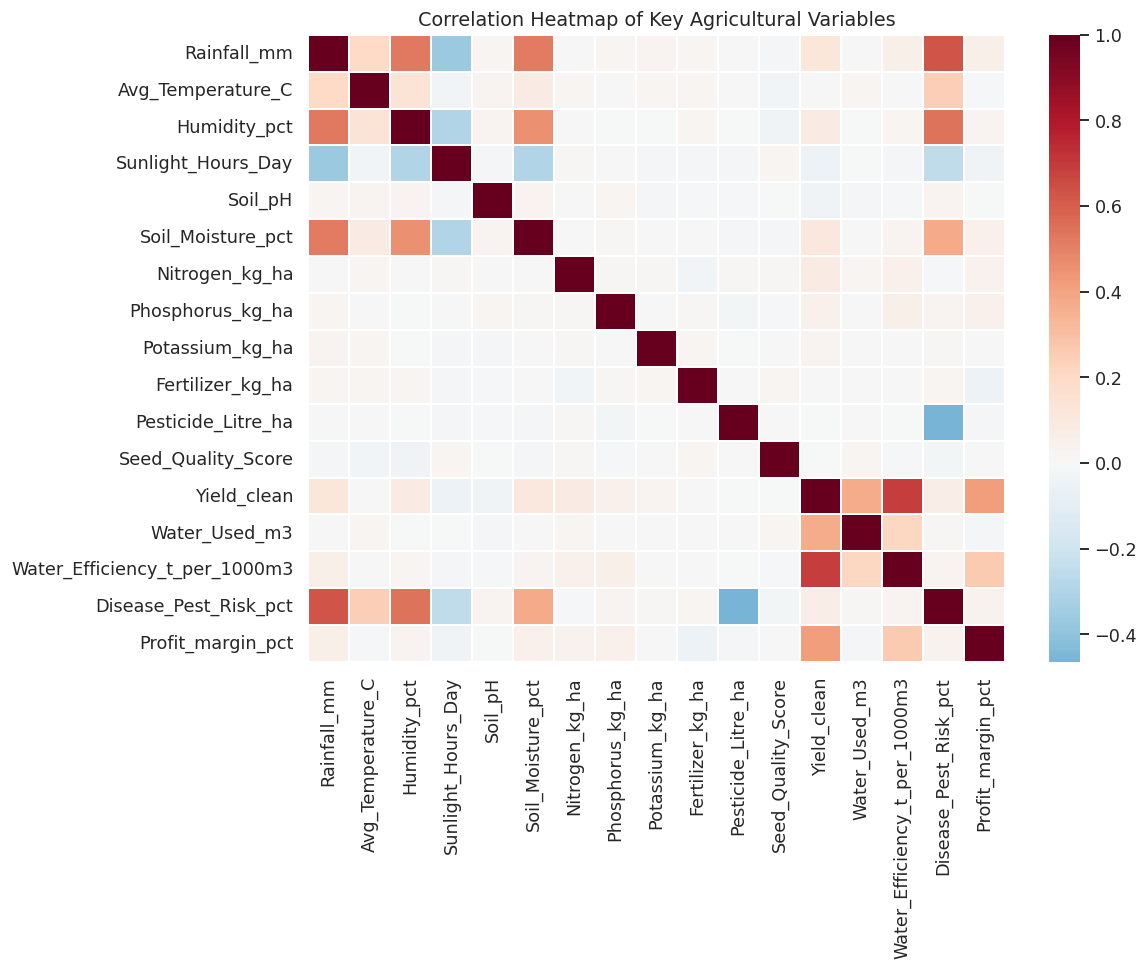

In [12]:
num_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH',
            'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha',
            'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_clean',
            'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct', 'Profit_margin_pct']
corr = df[num_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap='RdBu_r', center=0, linewidths=0.3)
plt.title('Correlation Heatmap of Key Agricultural Variables')
plt.tight_layout()
plt.show()

In [13]:
corr['Yield_clean'].sort_values(ascending=False)

Yield_clean                      1.000000
Water_Efficiency_t_per_1000m3    0.687617
Profit_margin_pct                0.417136
Water_Used_m3                    0.373950
Rainfall_mm                      0.122327
Soil_Moisture_pct                0.103306
Humidity_pct                     0.083344
Nitrogen_kg_ha                   0.081964
Disease_Pest_Risk_pct            0.066281
Phosphorus_kg_ha                 0.052672
Potassium_kg_ha                  0.032187
Fertilizer_kg_ha                 0.003007
Avg_Temperature_C               -0.000421
Seed_Quality_Score              -0.002850
Pesticide_Litre_ha              -0.004561
Soil_pH                         -0.037584
Sunlight_Hours_Day              -0.056643
Name: Yield_clean, dtype: float64

**Observation:** Water efficiency shows the strongest positive correlation with yield (r ≈ 0.69), and profit margin correlates positively with yield (r ≈ 0.42). Rainfall and soil moisture show only weak positive links, while fertilizer, pesticide use and soil pH show almost no correlation with yield — input *levels* alone don't explain seasonal yield gaps.

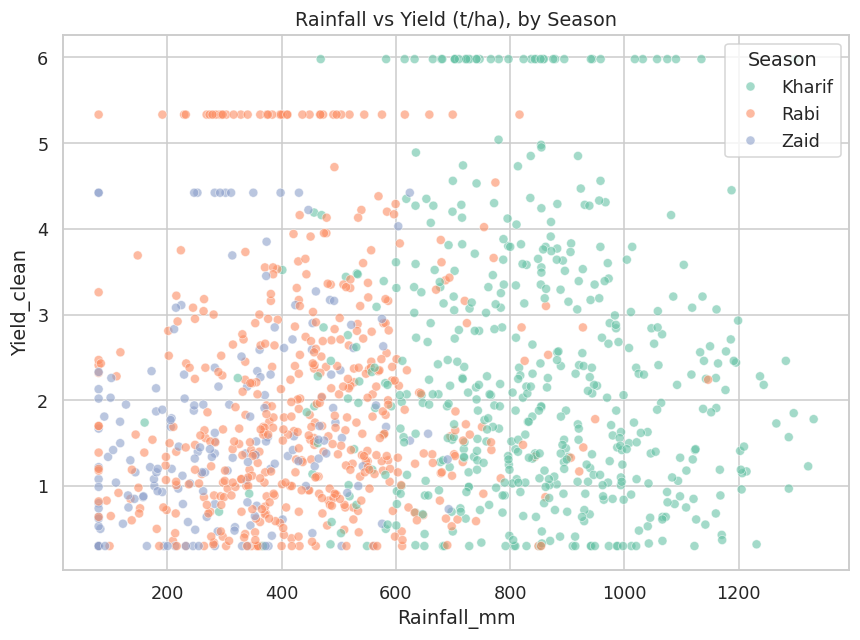

In [14]:
plt.figure(figsize=(8, 6))
sample = df.sample(min(1200, len(df)), random_state=42)
sns.scatterplot(data=sample, x='Rainfall_mm', y='Yield_clean', hue='Season', hue_order=season_order, alpha=0.6, s=35)
plt.title('Rainfall vs Yield (t/ha), by Season')
plt.tight_layout()
plt.show()

## 8. Question 6 — Are there unusual patterns in disease/pest risk and irrigation choices across seasons?

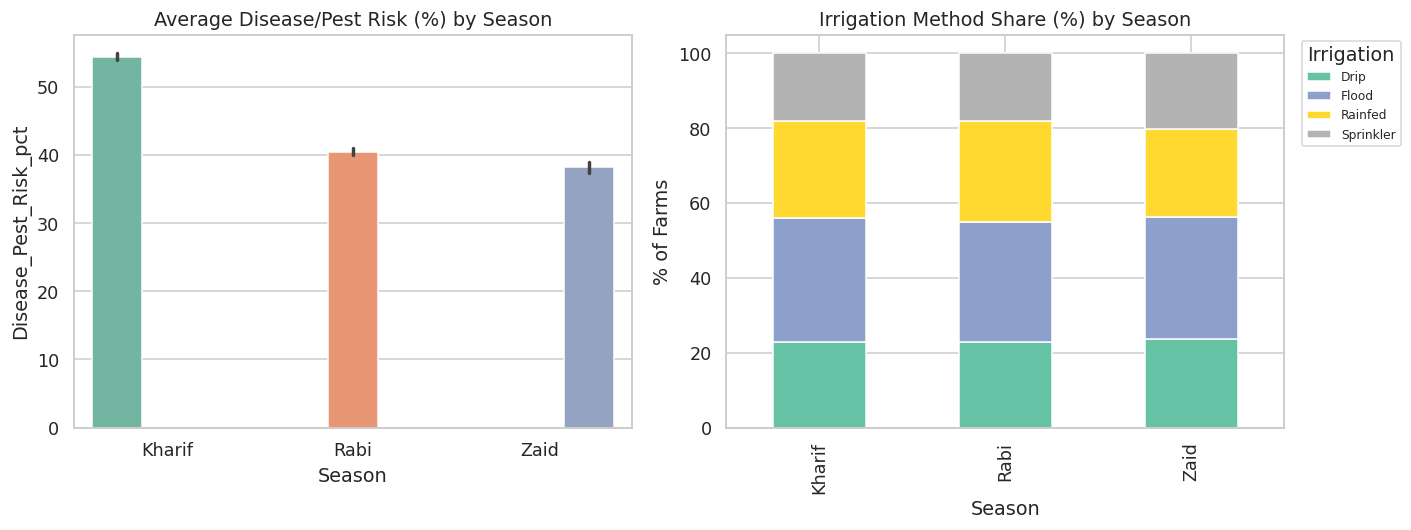

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=df, x='Season', y='Disease_Pest_Risk_pct', order=season_order, ax=axes[0], hue='Season', legend=False)
axes[0].set_title('Average Disease/Pest Risk (%) by Season')

irr = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').loc[season_order] * 100
irr.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Irrigation Method Share (%) by Season')
axes[1].set_ylabel('% of Farms')
axes[1].legend(title='Irrigation', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

**Observation:** Disease/pest risk is highest in Kharif (~54%), likely linked to its high rainfall and humidity, and lowest in Zaid (~38%).

## 9. Question 7 — Are seasonal yield patterns consistent across crops?

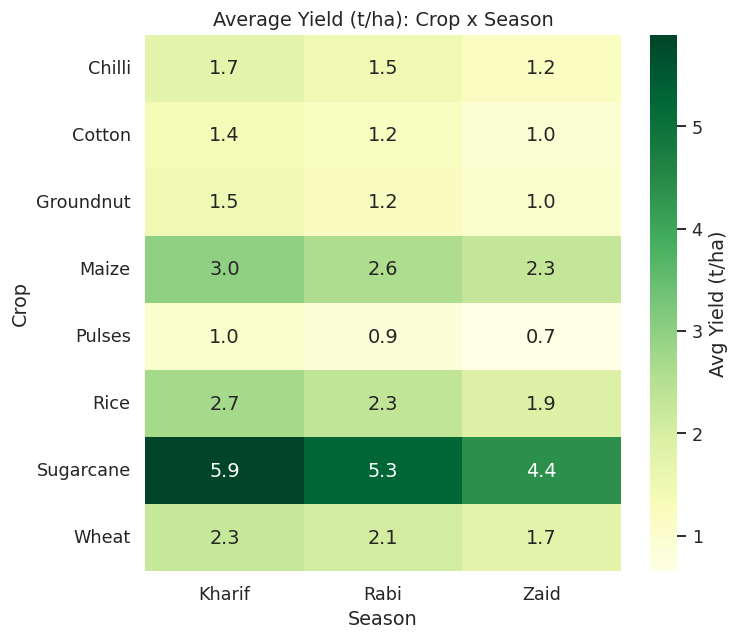

In [16]:
pivot_crop = df.pivot_table(index='Crop', columns='Season', values='Yield_clean', aggfunc='mean', observed=True)[season_order]
plt.figure(figsize=(7, 6))
sns.heatmap(pivot_crop, annot=True, fmt='.1f', cmap='YlGn', cbar_kws={'label': 'Avg Yield (t/ha)'})
plt.title('Average Yield (t/ha): Crop x Season')
plt.tight_layout()
plt.show()

**Observation:** The Kharif yield advantage is not uniform across every crop — some crops perform comparatively better in Rabi — showing that the "best" season also depends on which crop is being grown.

## 10. Question 8 — Are seasonal patterns consistent across states?

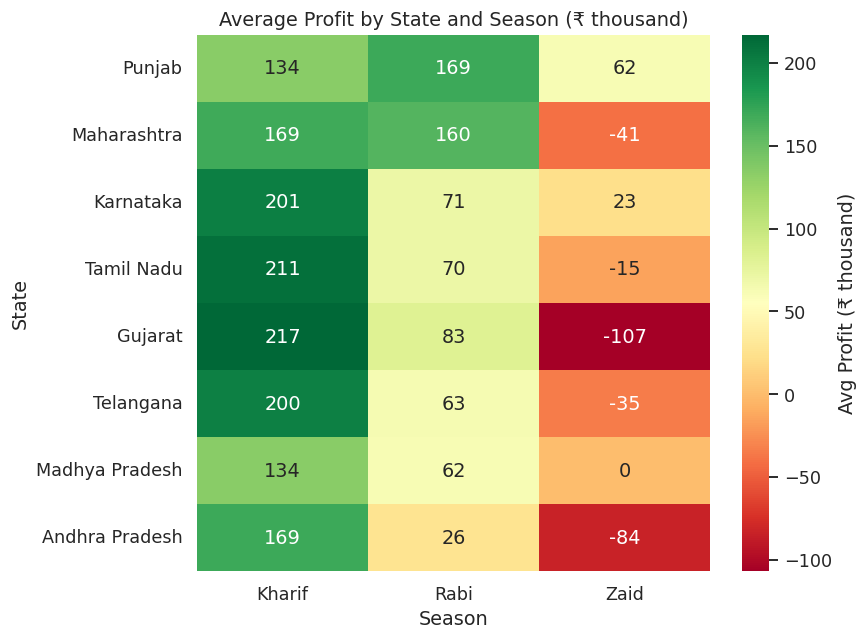

In [17]:
top_states = df.groupby('State', observed=True)['Profit_INR'].mean().sort_values(ascending=False).index
pivot_state = df.pivot_table(index='State', columns='Season', values='Profit_INR', aggfunc='mean', observed=True).loc[top_states][season_order]
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_state / 1000, annot=True, fmt='.0f', cmap='RdYlGn', cbar_kws={'label': 'Avg Profit (₹ thousand)'})
plt.title('Average Profit by State and Season (₹ thousand)')
plt.tight_layout()
plt.show()

**Observation:** Kharif outperforms the other seasons in most states, but the size of the gap — and in a few states, even the ranking of seasons — varies by state, pointing to local/regional factors beyond season alone.

## 11. Conclusions & Recommendations

**Does this dataset produce useful insight? Yes.** The analysis moves well beyond generic description — it identifies a consistently strongest and weakest season, isolates the actual driver of yield (irrigation efficiency, not input volume), and surfaces a clear economic risk pattern (negative margins, worst in Zaid) that a farmer, policymaker or lender could act on directly.

**Key findings**
1. **Kharif is the strongest season overall** — highest rainfall, highest average yield (~2.29 t/ha) and highest average profit (~₹1.79 lakh).
2. **Zaid is the weakest and riskiest season** — lowest yield (~1.71 t/ha), negative average profit (~₹−25K), and the widest spread of losses.
3. **Water efficiency, not fertilizer or water volume, is the strongest driver of yield** (r ≈ 0.69) — irrigation *quality* matters more than input *quantity*.
4. **Profit margins are negative on average in every season**, indicating that production costs frequently exceed revenue across a large share of farms, regardless of season.
5. **Disease/pest risk tracks rainfall and humidity**, peaking in the wet Kharif season.
6. **Seasonal advantage is not uniform** — it varies meaningfully by crop and by state, so recommendations should be localized rather than one-size-fits-all.

**Recommendations**
- Prioritize investment in irrigation efficiency (drip/sprinkler, scheduling) over simply increasing fertilizer or water volume.
- Treat Zaid-season cultivation as higher-risk — pair it with crop insurance or diversify into lower-risk crops for that season.
- Strengthen pest/disease surveillance and advisories specifically ahead of and during Kharif.
- Investigate the cost side of farm economics (input costs, market prices) given the broadly negative profit margins, alongside yield-side improvements.
- Build season-and-crop-specific (rather than generic) recommendations, since performance patterns differ by crop and by state.